In [1]:
import pandas as pd
import json
import numpy as np

Scores analysis

In [16]:
num_subjects = 12
num_trials = 17
excluded_subjects = {2, 7}
scores = np.zeros((num_subjects, num_trials))

for sub_id in range(1, num_subjects + 1):
    if sub_id in excluded_subjects:
        continue
    
    df_all_trials = pd.DataFrame()
    
    for trial_id in range(1, num_trials + 1):
        with open(f"data/sub_data/sub_{sub_id}/sub_{sub_id}_block_2_trial_{trial_id}.json") as file:
            data = json.load(file)
        
        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )

        scores[sub_id - 1, trial_id - 1] = df["server_result.score"].iloc[-1]
        

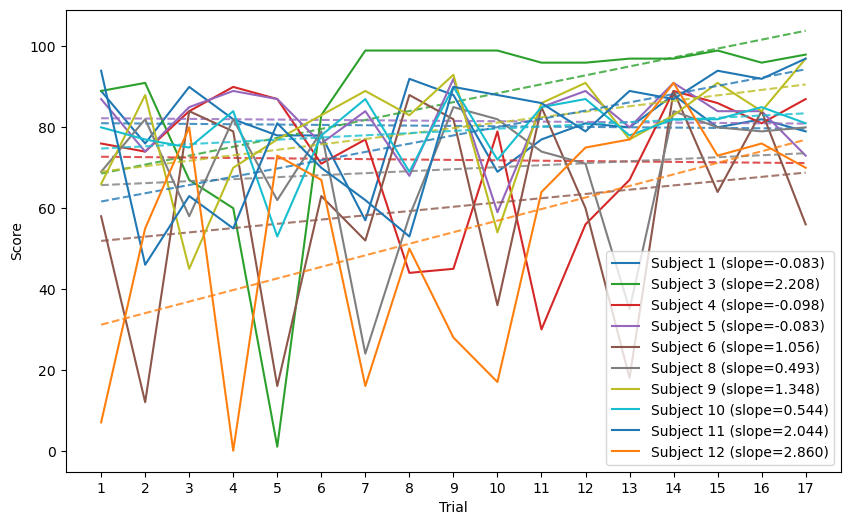

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
trial_numbers = np.arange(1, 18)

for sub_id in range(1, num_subjects + 1):
    if sub_id in excluded_subjects:
        continue

    subject_color = f'C{sub_id - 1}'
    slope, intercept = np.polyfit(trial_numbers, scores[sub_id - 1], 1)
    fitted_scores = slope * trial_numbers + intercept

    ax.plot(range(1, 18), scores[sub_id - 1], color=subject_color, label=f'Subject {sub_id} (slope={slope:.3f})')
    ax.plot(range(1, 18), fitted_scores, linestyle='--', color=subject_color, alpha=0.8)
    ax.set_xticks(range(1, 18))
    ax.set_ylabel("Score")
    ax.set_xlabel("Trial")

plt.legend()
plt.show()

Difference between desired and recommended values

In [10]:
num_subjects = 12
num_trials = 17
max_submissions = 5

# Trials with fewer than five submissions retain NaN in unused positions.
# diffs = np.full((num_subjects, num_trials, max_submissions), np.nan)
diffs = np.zeros((num_subjects, num_trials))

for sub_id in range(1, num_subjects + 1):
    for trial_id in range(1, num_trials + 1):
        with open(f"data/sub_data/sub_{sub_id}/sub_{sub_id}_block_2_trial_{trial_id}.json") as file:
            data = json.load(file)

        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )

        slider_values_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["slider_values"], df["slider_maxs"])
        ])
        rec_values_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["server_result.rec"], df["slider_maxs"])
        ])
        diff_values_frac = np.round(slider_values_frac - rec_values_frac, 2)
        # diff = np.sum(diff_values_frac, axis=1)
        diff = np.sum(diff_values_frac)

        # diffs[sub_id - 1, trial_id - 1, :len(diff)] = diff
        diffs[sub_id - 1, trial_id - 1] = diff

# One row per subject; columns combine trials and submission slots.
# diffs_flat = diffs.reshape(num_subjects, -1)
# print(diffs_flat.shape)
# diffs_list = [
#     diffs_flat[i][~np.isnan(diffs_flat[i])] for i in range(num_subjects)
# ]

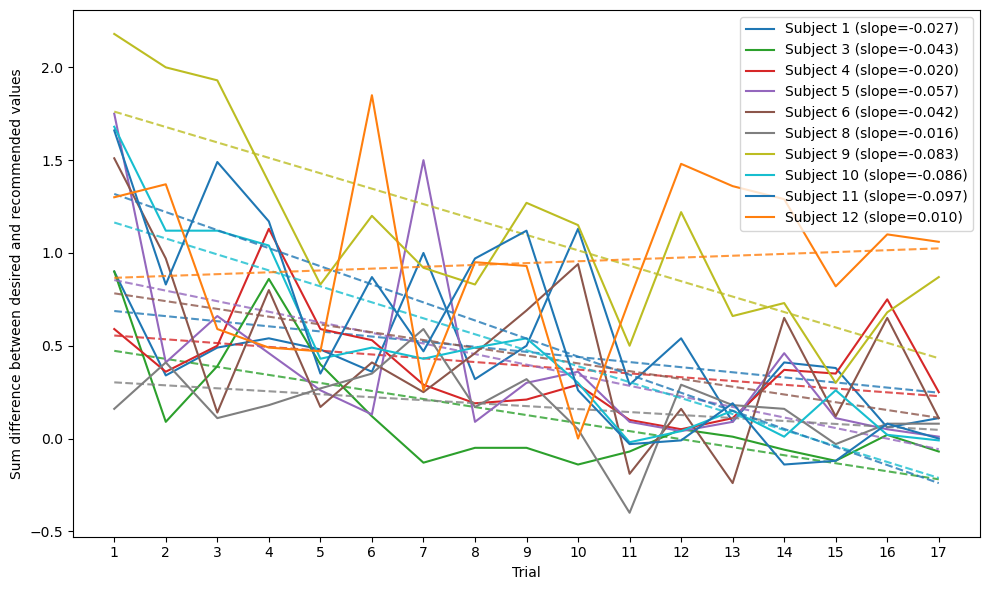

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
trial_numbers = np.arange(1, 18)

excluded_subjects = {2, 7}

for sub_id, subject_diffs in enumerate(diffs, start=1):
    if sub_id in excluded_subjects:
        continue

    subject_color = f'C{sub_id - 1}'
    slope, intercept = np.polyfit(trial_numbers, subject_diffs, 1)
    fitted_diffs = slope * trial_numbers + intercept

    ax.plot(
        trial_numbers,
        subject_diffs,
        color=subject_color,
        label=f'Subject {sub_id} (slope={slope:.3f})',
    )
    ax.plot(
        trial_numbers,
        fitted_diffs,
        linestyle='--',
        color=subject_color,
        alpha=0.8,
    )

ax.set_xticks(trial_numbers)
# ax.set_ylim(-1, 2)
ax.set_xlabel('Trial')
ax.set_ylabel('Sum difference between desired and recommended values')
ax.legend()
fig.tight_layout()
plt.show()

All information displayed

In [4]:
sub_id = 3

df_all_trials = pd.DataFrame()
for trial_id in range(1, 18):
    with open(f"data/sub_data/sub_{sub_id}/sub_{sub_id}_block_2_trial_{trial_id}.json") as file:
        data = json.load(file)
    
    df = pd.json_normalize(
        data,
        record_path="submissions",
        meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
    )

    df["server_result.mrs"] = df["server_result.mrs"].shift(1) # shift mrs down by one row
    
    df_all_trials = pd.concat([df_all_trials, df])

In [ ]:
info = pd.DataFrame({
    "trial_id": df_all_trials["trial_id"],
    "submission_number": df_all_trials["submission_number"],
    "initial_slider_values": df_all_trials["initial_slider_values"],
    "slider_values": df_all_trials["slider_values"]
})
mrs = [
    np.round(np.asarray(values), 2)
    if values is not None
    else np.array([])
    for values in df_all_trials["server_result.mrs"]
]
# mrs_flat = [
#     np.round(np.asarray(values), 2).ravel()
#     if values is not None
#     else np.array([])
#     for values in df_all_trials["server_result.mrs"]
# ]
initial_slider_values_frac = [
    np.asarray(values) / np.asarray(maxs)
    for values, maxs in zip(df_all_trials["initial_slider_values"], df_all_trials["slider_maxs"])
]
slider_values_frac = [
    np.asarray(values) / np.asarray(maxs)
    for values, maxs in zip(df_all_trials["slider_values"], df_all_trials["slider_maxs"])
]
rec_values_frac = [
    np.asarray(values) / np.asarray(maxs)
    for values, maxs in zip(df_all_trials["server_result.rec"], df_all_trials["slider_maxs"])
]
slider_value_changes_frac = [
    np.round(slider_value - initial_slider_value, 2)
    for slider_value, initial_slider_value in zip(slider_values_frac, initial_slider_values_frac)
]
diff_values_frac = [
    np.round(slider_value - rec_value, 2)
    for slider_value, rec_value in zip(slider_values_frac, rec_values_frac)
]
# positive diff means not reachable objective values
# negative diff means too conservative

info["slider_value_changes_frac"] = slider_value_changes_frac
info["diff_values_frac"] = diff_values_frac
info["mrs"] = mrs
info["score"] = df_all_trials["server_result.score"]
info.to_csv(f"sub_{sub_id}_info.csv", index=False)
info.head()

,trial_id,submission_number,initial_slider_values,slider_values,slider_value_changes_frac,diff_values_frac,mrs,score
0,1,1,"[76.8, 38.5, 14.5, 13.9, 146.6]","[102.16, 44.98, 16.28, 1.48, 180.46]","[0.21, 0.08, 0.08, -0.4, 0.17]","[0.37, 0.0, 0.02, -0.02, 0.0]",[],60
1,1,2,"[56.6, 44.7, 15.9, 2.2, 180.0]","[89.17, 25.65, 17.32, 2.2, 180.0]","[0.27, -0.22, 0.06, 0.0, 0.0]","[0.2, -0.02, 0.08, -0.04, 0.0]","[[0.0, -1.23, -0.8, -0.07, -1.3], [-0.35, 0.0,...",14
2,1,3,"[65.1, 27.7, 15.4, 3.3, 179.8]","[55.18, 60.76, 3.76, 19.0, 183.62]","[-0.08, 0.39, -0.52, 0.51, 0.02]","[0.0, 0.15, -0.21, 0.28, 0.07]","[[0.0, -1.53, -1.51, 1.24, -0.98], [-0.13, 0.0...",5
3,1,4,"[54.6, 47.8, 8.6, 10.5, 169.9]","[43.91, 51.95, 18.1, 0.88, 185.2]","[-0.09, 0.05, 0.42, -0.31, 0.08]","[-0.0, -0.0, 0.02, -0.02, 0.02]","[[0.0, -0.16, 0.12, -0.08, 0.0], [-2.0, 0.0, 0...",89
0,2,1,"[79.7, 37.3, 15.0, 14.2, 144.6]","[80.15, 10.05, 19.83, 0.75, 173.03]","[0.0, -0.3, 0.2, -0.41, 0.14]","[0.01, -0.18, 0.11, -0.12, 0.01]",[],45


In [78]:
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_rows", None,
):
    display(info[["slider_value_changes_frac", "mrs"]])

,slider_value_changes_frac,mrs
0,"[0.21, 0.08, 0.08, -0.4, 0.17]",[]
1,"[0.27, -0.22, 0.06, 0.0, 0.0]","[[0.0, -1.23, -0.8, -0.07, -1.3], [-0.35, 0.0, 0.14, -0.62, -0.71], [-0.02, 0.45, 0.0, 0.14, -0.38], [-0.14, -1.32, 0.79, 0.0, -0.41], [-0.23, -0.39, -0.47, -0.44, 0.0]]"
2,"[-0.08, 0.39, -0.52, 0.51, 0.02]","[[0.0, -1.53, -1.51, 1.24, -0.98], [-0.13, 0.0, -0.26, -0.07, -0.18], [-0.65, -0.62, 0.0, 0.47, -0.67], [0.15, -0.31, 0.18, 0.0, 0.01], [-0.9, -1.39, -1.5, 0.57, 0.0]]"
3,"[-0.09, 0.05, 0.42, -0.31, 0.08]","[[0.0, -0.16, 0.12, -0.08, 0.0], [-2.0, 0.0, 0.41, -1.4, -1.19], [0.3, 0.22, 0.0, 0.17, 0.22], [-1.16, -0.85, 0.26, 0.0, -1.11], [-1.05, -0.8, 0.37, -1.01, 0.0]]"
0,"[0.0, -0.3, 0.2, -0.41, 0.14]",[]
1,"[-0.16, 0.31, 0.11, 0.0, 0.04]","[[0.0, -0.19, -1.57, 0.14, -1.67], [0.52, 0.0, 0.56, -0.11, -0.34], [-1.12, 0.55, 0.0, -0.01, -1.31], [0.69, -0.73, 1.2, 0.0, -0.23], [-1.1, 0.14, -1.48, 0.06, 0.0]]"
2,"[0.0, 0.04, 0.05, 0.0, 0.04]","[[0.0, -0.63, -0.47, -0.68, -0.38], [-0.33, 0.0, -0.43, -0.9, -0.61], [-0.3, -0.62, 0.0, -0.59, -0.5], [0.08, -0.24, -0.11, 0.0, -0.24], [-0.18, -0.64, -0.47, -0.41, 0.0]]"
0,"[0.2, -0.17, 0.16, -0.21, 0.14]",[]
1,"[-0.22, 0.43, 0.0, -0.16, 0.0]","[[0.0, -1.45, -0.85, 0.52, -0.75], [-0.34, 0.0, -0.27, -0.11, -0.45], [-0.83, -0.39, 0.0, 0.27, -0.56], [-0.0, -0.04, 0.01, 0.0, -0.24], [-0.97, -1.24, -0.9, -0.09, 0.0]]"
2,"[-0.07, 0.0, 0.07, 0.0, 0.03]","[[0.0, -1.04, -1.21, 0.01, -0.95], [-0.67, 0.0, -1.41, -0.06, -1.1], [-0.2, -0.45, 0.0, 0.24, -0.48], [0.42, 0.51, 0.59, 0.0, 0.62], [-0.38, -0.64, -0.92, 0.27, 0.0]]"


Regression between mrs and slider value change

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

valid_rows = info["mrs"].notna() & info["slider_value_changes_frac"].notna()
model_data = info.loc[valid_rows].copy()

mrs_matrices = np.stack(model_data["mrs"].map(lambda value: np.asarray(value, dtype=float)))
y = np.stack(
    model_data["slider_value_changes_frac"].map(lambda value: np.asarray(value, dtype=float))
)

n_objectives = mrs_matrices.shape[1]
off_diagonal = ~np.eye(n_objectives, dtype=bool)
X = mrs_matrices[:, off_diagonal]
feature_names = [
    f"mrs_{i}_{j}"
    for i in range(n_objectives)
    for j in range(n_objectives)
    if i != j
]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

metrics = pd.DataFrame({
    "objective": np.arange(n_objectives),
    "r2": r2_score(y_test, y_pred, multioutput="raw_values"),
    "mae": mean_absolute_error(y_test, y_pred, multioutput="raw_values"),
})
print(f"Train observations: {len(X_train)}, test observations: {len(X_test)}")
display(metrics)

Train observations: 16, test observations: 4


,objective,r2,mae
0,0,-2.362086,0.248795
1,1,-8.722599,0.634669
2,2,0.015291,0.215075
3,3,-3.407425,0.369529
4,4,-1.702012,0.039355


In [ ]:
# per objective regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

valid_rows = info["mrs"].notna() & info["slider_value_changes_frac"].notna()
model_data = info.loc[valid_rows].copy()

mrs_matrices = np.stack(model_data["mrs"].map(lambda value: np.asarray(value, dtype=float)))
y = np.stack(
    model_data["slider_value_changes_frac"].map(lambda value: np.asarray(value, dtype=float))
)

n_objectives = mrs_matrices.shape[1]
off_diagonal = ~np.eye(n_objectives, dtype=bool)
X = mrs_matrices[:, off_diagonal]

In [ ]:
metrics = []

for i in range(n_objectives):
    X_i = X[:, i*4:(i+1)*4]
    y_i = y[:, i]
    X_train, X_test, y_train, y_test = train_test_split(X_i, y_i, test_size=0.1, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics.append({
        "objective": i,
        "r2": r2_score(y_test, y_pred),
        "mae": mean_absolute_error(y_test, y_pred),
    })

metrics = pd.DataFrame(metrics)
display(metrics)

Tradeoff knowledge analysis

In [6]:
from itertools import combinations

corrs_by_year = {}
for year in range(2000, 2017):
    items_df = pd.read_csv(f"data/items/items_{year}.csv").drop(columns=["PLAYER", "SALARY"])
    objective_names = items_df.columns.to_numpy()
    corrs = items_df.corr().to_numpy()
    
    pair_corrs = {
        (objective_names[i], objective_names[j]): corrs[i, j]
        for i, j in combinations(range(len(objective_names)), 2)
    }
    corrs_by_year[year] = dict(
        sorted(pair_corrs.items(), key=lambda pair: pair[1], reverse=True)
    )

In [7]:
corrs_by_year[2000]

{('REB', 'BLK'): 0.6660470804011918,
 ('AST', 'STL'): 0.420890570545374,
 ('AST', 'PTS'): 0.11402397359995406,
 ('STL', 'PTS'): 0.026753897444125325,
 ('REB', 'PTS'): -0.031188122313227817,
 ('BLK', 'PTS'): -0.06875652040946625,
 ('STL', 'BLK'): -0.2793484128040412,
 ('REB', 'STL'): -0.305501510963121,
 ('AST', 'BLK'): -0.47241904808582785,
 ('REB', 'AST'): -0.5849952136384738}

In [19]:
len(corrs_by_year[2000])

10

In [8]:
num_subjects = 10
objective_order = {name: i for i, name in enumerate(objective_names)}

def tradeoff_key(values):
    return tuple(sorted(values, key=objective_order.get))

for sub_id in range(1, num_subjects + 1):
    with open(f"data/sub_data/sub_{sub_id}/sub_{sub_id}_block_2_query.json") as file:
            data = json.load(file)
        
    df = pd.json_normalize(data)
    small_tradeoff = df["largest_tradeoff_1"][0]
    large_tradeoff = df["largest_tradeoff_2"][0]
    small_tradeoff_key = tradeoff_key(small_tradeoff)
    large_tradeoff_key = tradeoff_key(large_tradeoff)

    print(sub_id, small_tradeoff_key, large_tradeoff_key)

    
    small_rank = []
    large_rank = []
    for year in range(2000, 2017):
        keys = list(corrs_by_year[year].keys())
        small_index = keys.index(small_tradeoff_key)
        large_index = keys.index(large_tradeoff_key)

        small_rank.append(small_index)
        large_rank.append(large_index)

        avg_small_rank = np.asarray(small_rank).mean()
        avg_large_rank = np.asarray(large_rank).mean()

    print(int(avg_small_rank))
    print(int(avg_large_rank))
    print("--------------------------------")


1 ('STL', 'PTS') ('REB', 'AST')
3
9
--------------------------------
2 ('STL', 'PTS') ('AST', 'BLK')
3
8
--------------------------------
3 ('AST', 'STL') ('REB', 'AST')
1
9
--------------------------------
4 ('BLK', 'PTS') ('REB', 'AST')
5
9
--------------------------------
5 ('STL', 'PTS') ('AST', 'BLK')
3
8
--------------------------------
6 ('BLK', 'PTS') ('REB', 'AST')
5
9
--------------------------------
7 ('REB', 'BLK') ('AST', 'BLK')
0
8
--------------------------------
8 ('STL', 'PTS') ('REB', 'AST')
3
9
--------------------------------
9 ('AST', 'PTS') ('AST', 'BLK')
2
8
--------------------------------
10 ('STL', 'PTS') ('REB', 'AST')
3
9
--------------------------------


/tmp/ipykernel_712300/2911026258.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


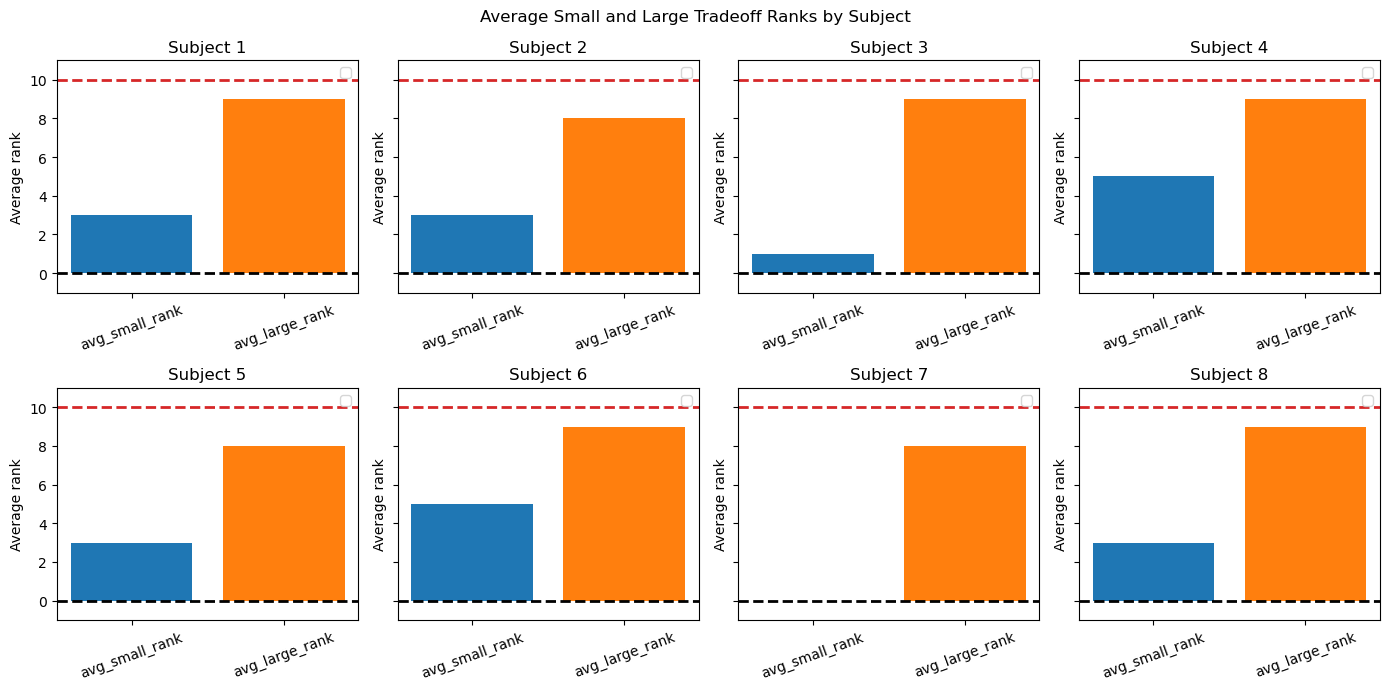

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharey=True)
axes = axes.ravel()

for sub_id, ax in zip(range(1, num_subjects + 1), axes):
    with open(f"data/sub_data/sub_{sub_id}/sub_{sub_id}_block_2_query.json") as file:
        data = json.load(file)

    df = pd.json_normalize(data)
    small_tradeoff_key = tradeoff_key(df["largest_tradeoff_1"][0])
    large_tradeoff_key = tradeoff_key(df["largest_tradeoff_2"][0])

    small_ranks = []
    large_ranks = []
    for year in range(2000, 2017):
        ranked_tradeoffs = list(corrs_by_year[year].keys())
        small_ranks.append(ranked_tradeoffs.index(small_tradeoff_key))
        large_ranks.append(ranked_tradeoffs.index(large_tradeoff_key))

    avg_small_rank = np.mean(small_ranks)
    avg_large_rank = np.mean(large_ranks)
    ax.bar(
        ["avg_small_rank", "avg_large_rank"],
        [avg_small_rank, avg_large_rank],
        color=["tab:blue", "tab:orange"],
    )
    ax.set_title(f"Subject {sub_id}")
    ax.tick_params(axis="x", labelrotation=20)
    ax.set_ylabel("Average rank")
    ax.set_ylim(-1, 11)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=2)
    ax.axhline(y=10, color='C3', linestyle='--', linewidth=2)
    ax.legend()

fig.suptitle("Average Small and Large Tradeoff Ranks by Subject")
fig.tight_layout()
plt.show()